## `photoz_bias.ipynb`

-----------------------

This notebook measures and models the photoz galaxy bias given scale cuts.

In [1]:
import numpy as np 
import importlib
import matplotlib.pyplot as plt

from matplotlib.lines import Line2D
from matplotlib.patches import Patch
from matplotlib.ticker import MultipleLocator
from pathlib import Path
from scipy.integrate import simpson
from pycorr import TwoPointEstimator

import src.statistics.inference as inference
import src.statistics.combination as comb
import src.statistics.cosmotools as ct
import src.statistics.corrfiles as cf
import src.statistics.sgp as sgp

# Methods:
----------

We use the [Euclid](https://arxiv.org/pdf/2208.10503) approach (derived from Schmidt+2013):

We use : 
$n_{p, m}(z_{j, t})\propto \frac{\bar{\omega}_{\rm{sp},\:m}(r,\:z_{j, t})}{\sqrt{\bar{\omega}_{\rm{ss}}(r,\:z_{j, t})\bar{\omega}_{\rm{pp},\:m}(r)}}$ with $\bar{\omega}_{xy}(r, z_j)=\int_{r_{min}}^{r_{max}}W(r)\omega_{xy}(r, z_j)$ the scale averaged two point correlation function between samples x, y.

- $z_{j, t}$ : center of the fine bin j for the t tracer (ELG, LRG ...)
- $m$ : id of the tomographic bin
- $s$ : spectroscopic sample
- $p$ : photometric sample

Cosmology used (for distances in $h^{-1}Mpc$) :
- $\Omega_c = 0.258868$ (cold dark matter density fraction)
- $\Omega_b = 0.048252$ (baryon density fraction)
- $\Omega_m=\Omega_c+\Omega_b$ (matter density fraction)
- $h = 0.6777$
- $H_0 = h * 100$
- $\sigma_8 = 0.8$
- $n_s = 0.95$

DES Y3 Approach :

-----------------

$n_{p, m}(z_{j, t})\propto\frac{\bar{\omega}_{\rm{sp},\:m}(r,\:z_{j, t})}{\sqrt{\bar{\omega}_{\rm{ss}}(r,\:z_{j, t})\bar{\omega}_{\rm{pp},\:m}(r, z_{j, t})\sigma_j}}$ with $\bar{\omega}_{xy}(r, z_j)=\int_{r_{min}}^{r_{max}}W(r)\omega_{xy}(r, z_j)$

This approach does not really work well due to the very high variations in $\sigma_j$ caused by the photometric method itself (redshift spikes)


In [2]:
ROOT = Path('/global/cfs/projectdirs/desi/users/jchdj/desi-y3-hsc/src/statistics/outputs/')
bins_hsc = np.arange(0.3, 1.8, 0.3)

markers = ['x', 's', '^', 'D']
linestyles = ['-', '--', '-.', ':']
colormaps = [plt.get_cmap(c) for c in ['Reds', 'Blues', 'Greens', 'Purples']]
colors = [cmap(0.8) for cmap in colormaps]
tracers = ['BGS_ANY', 'LRG', 'ELGnotqso', 'QSO']
tracer_trad = {
    'BGS_ANY' : 'BGS',
    'LRG' : 'LRG',
    'ELGnotqso' : 'ELG',
    'QSO' : 'QSO',
}

In [5]:
stem = 'v12_correction'
path_dictionary = {
    'HSC' : ROOT / stem / f'autos_HSC',
    'DESI_NGC' : ROOT / stem / f'autos_NGC',
    'DESI_SGC' : ROOT / stem / f'autos_SGC',
    'DESIxHSC' : ROOT / stem / f'cross',
}
outdir = ROOT / f'merged_{stem}'
path_dictionary.update({
    'MergedxMerged' : outdir,
    'MergedxHSC' : outdir,
})
assert all([p.exists() for p in path_dictionary.values()])

In [ ]:
importlib.reload(inference)
importlib.reload(comb)
importlib.reload(ct)
importlib.reload(cf)
inference.merge_estimators(
    path_dictionary=path_dictionary, 
    outdir=outdir, 
    verbose=True,
    which_tomo='all'
    )

Processing redshift bin 0 (Completion : 1.79%)
Processing redshift bin 5 (Completion : 10.71%)
Processing redshift bin 10 (Completion : 19.64%)
Processing redshift bin 15 (Completion : 28.57%)
Processing redshift bin 20 (Completion : 37.50%)
Processing redshift bin 25 (Completion : 46.43%)
Processing redshift bin 30 (Completion : 55.36%)
Processing redshift bin 35 (Completion : 64.29%)
Processing redshift bin 40 (Completion : 73.21%)
Processing redshift bin 45 (Completion : 82.14%)
Processing redshift bin 50 (Completion : 91.07%)
Processing redshift bin 55 (Completion : 100.00%)
Saved cross-correlation estimator to /global/cfs/projectdirs/desi/users/jchdj/desi-y3-hsc/src/statistics/outputs/merged_v15_dr1/MergedxHSC/MergedxHSC_b1x1_b2x1.npy
Saved cross-correlation estimator to /global/cfs/projectdirs/desi/users/jchdj/desi-y3-hsc/src/statistics/outputs/merged_v15_dr1/MergedxHSC/MergedxHSC_b1x1_b2x2.npy
Saved cross-correlation estimator to /global/cfs/projectdirs/desi/users/jchdj/desi-y3-

In [ ]:
tracer = 'Merged'
correction_file_reader = cf.CorrFileReader(path_dictionary["HSC"])
bins_z_photo = inference._get_fine_redshift_bins(
    fr=correction_file_reader,
    tracer='HSC'
)
vals_z_photo = (bins_z_photo[:-1] + bins_z_photo[1:]) / 2
correction_file_reader = cf.CorrFileReader(path_dictionary["DESI_NGC"])
bins_z_spectro = inference._get_fine_redshift_bins(
    fr=correction_file_reader,
    tracer='Merged'
)
vals_z_spectro = (bins_z_spectro[:-1] + bins_z_spectro[1:]) / 2

In [28]:
importlib.reload(inference)
importlib.reload(comb)
importlib.reload(ct)
importlib.reload(cf)
nz = []
nz_err = []
for i in range(1, len(bins_z_photo)):
    meas = inference.full_npz_tomo(
        path_dictionary=path_dictionary,
        do_bias_correction=False,
        scale_cuts=[.3, 2.5],
        tracer='Merged',
        tomo_bin=i,
    )
    nz.append(meas[0])
    nz_err.append(meas[1])
nz = np.array(nz)
nz_err = np.array(nz_err)

Using merged method for tracer Merged and tomo bin 1.
Using merged method for tracer Merged and tomo bin 2.
Using merged method for tracer Merged and tomo bin 3.
Using merged method for tracer Merged and tomo bin 4.
Using merged method for tracer Merged and tomo bin 5.
Using merged method for tracer Merged and tomo bin 6.
Using merged method for tracer Merged and tomo bin 7.
Using merged method for tracer Merged and tomo bin 8.
Using merged method for tracer Merged and tomo bin 9.
Using merged method for tracer Merged and tomo bin 10.
Using merged method for tracer Merged and tomo bin 11.
Using merged method for tracer Merged and tomo bin 12.
Using merged method for tracer Merged and tomo bin 13.
Using merged method for tracer Merged and tomo bin 14.
Using merged method for tracer Merged and tomo bin 15.
Using merged method for tracer Merged and tomo bin 16.
Using merged method for tracer Merged and tomo bin 17.
Using merged method for tracer Merged and tomo bin 18.
Using merged method

In [75]:
importlib.reload(sgp)
ind = 4
suppresion = sgp.suppression(
    zval=vals_z_photo,
    gp_n=nz[ind],
    gp_sigma=nz_err[ind]
)
mean, uncertainty = sgp.suppress_nz(
    zval=vals_z_spectro,
    gp_n=nz[ind],
    gp_sigma=nz_err[ind]
)

Text(0, 0.5, 'Number density')

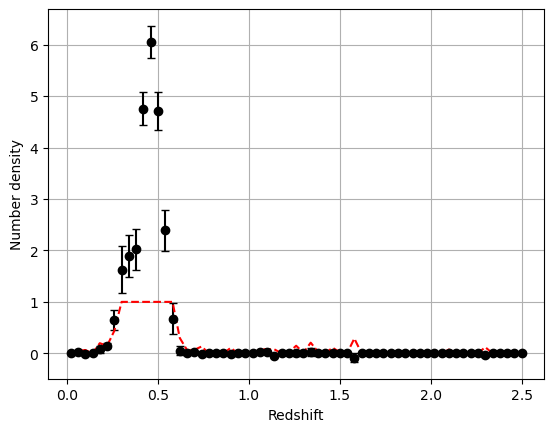

In [76]:
plt.errorbar(
    vals_z_spectro, 
    mean, 
    yerr=uncertainty, 
    fmt='o', 
    color='black', 
    label='Suppressed GP',
    capsize=3
)
plt.plot(
    vals_z_spectro, 
    suppresion, 
    color='red', 
    label='GP',
    linestyle='--'
)
plt.grid()
plt.xlabel('Redshift')
plt.ylabel('Number density')

In [88]:
calib_nz = []
calib_nz_err = []
for ind in range(len(bins_z_photo)-1):
    mean, uncertainty = sgp.suppress_nz(
        zval=vals_z_spectro,
        gp_n=nz[ind],
        gp_sigma=nz_err[ind]
    )
    calib_nz.append(mean)
    calib_nz_err.append(uncertainty)
calib_nz = np.array(calib_nz)
calib_nz_err = np.array(calib_nz_err)

Text(0, 0.5, 'Number density')

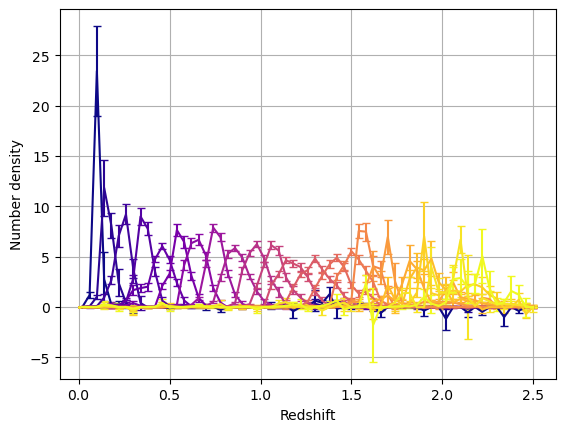

In [91]:
colormap = plt.get_cmap('plasma')
for i in range(len(vals_z_photo)):
    plt.errorbar(
        vals_z_spectro, 
        calib_nz[i], 
        yerr=calib_nz_err[i],
        color=colormap(i / (len(vals_z_photo)-1)),
        capsize=3
    )
plt.grid()
plt.xlabel('Redshift')
plt.ylabel('Number density')

Using simple scheme for effective redshift calculation.
Using simple scheme for effective redshift calculation.
Using simple scheme for effective redshift calculation.
Using simple scheme for effective redshift calculation.
Using simple scheme for effective redshift calculation.
Using simple scheme for effective redshift calculation.
Using simple scheme for effective redshift calculation.
Using simple scheme for effective redshift calculation.
Using simple scheme for effective redshift calculation.
Using simple scheme for effective redshift calculation.
Using simple scheme for effective redshift calculation.
Using simple scheme for effective redshift calculation.
Using simple scheme for effective redshift calculation.
Using simple scheme for effective redshift calculation.
Using simple scheme for effective redshift calculation.
Using simple scheme for effective redshift calculation.
Using simple scheme for effective redshift calculation.
Using simple scheme for effective redshift calcu

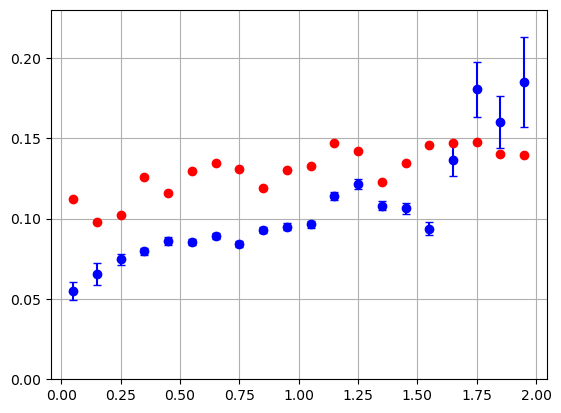

In [ ]:
importlib.reload(inference)
importlib.reload(comb)
wpp = []
wpp_err = []
zeff = []
for i in range(1, len(stds)+1):
    ## now let's get the wpp measurements to get the full correction
    wpp_meas, wpp_err_meas, _ = inference.wpp(
            path=path_dictionary['HSC'],
            scale_cuts=[.2, 3],
            bin_index=i,
        )
    wpp_err.append(wpp_err_meas)
    wpp.append(wpp_meas)
    zeff.append(cf.get_zeff(zlow=(i-1)*0.1, zhigh=i*0.1, type='HSC', scheme='simple'))
print(f'zeff = {zeff}')
print(f'wpp = {wpp}')
print(f'wpp_err = {wpp_err}')
errs = comb.combine_error_bars_mult(wpp, wpp_err, stds, stds_err)
vals = np.sqrt(np.array(wpp)*np.array(stds))
#plt.plot(means, np.sqrt(np.array(wpp)*np.array(stds)), label='wpp')
plt.errorbar(zeff, vals, errs, label='correction', capsize=3, fmt='o', color='blue')
plt.errorbar(zeff, wpp, wpp_err, label='wpp', capsize=3, fmt='o', color='red')
plt.ylim(0, 0.23)
plt.grid()

Number of non-NaN values: 20

Fitted power law:
  a = 0.06444603635845615 ± 0.0014841360379849915
  gamma = 0.6105475676920177 ± 0.03521149667406503


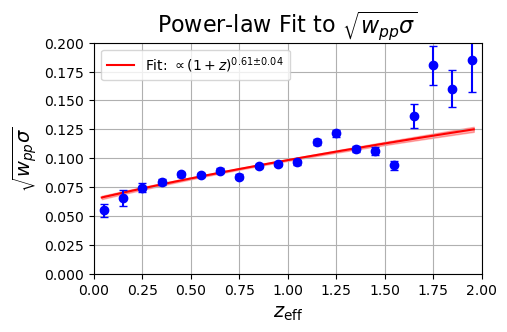

In [52]:
from scipy.optimize import curve_fit

def power_law(z, a, gamma):
    return a * (1 + z)**gamma

# Var(f) ≈ (df/da)^2 * Var(a) + (df/dγ)^2 * Var(γ) + 2*Cov(a,γ)*df/da*df/dγ
def power_law_error(z, a, gamma, pcov):
    da = (1 + z)**gamma
    dgamma = a * (1 + z)**gamma * np.log(1 + z)
    var = (
        da**2 * pcov[0, 0] +
        dgamma**2 * pcov[1, 1] +
        2 * da * dgamma * pcov[0, 1]
    )
    return np.sqrt(var)

nonnan_mask = ~np.isnan(np.array(vals))
print(f"Number of non-NaN values: {np.sum(nonnan_mask)}")
zeff_arr = np.array(zeff)[nonnan_mask]
vals_arr = np.array(vals)[nonnan_mask]
errs_arr = np.array(errs)[nonnan_mask]

p0 = [np.mean(vals_arr), 1.0]

popt, pcov = curve_fit(
    power_law, zeff_arr, vals_arr, p0=p0, sigma=errs_arr, absolute_sigma=True
)
a_fit, gamma_fit = popt
a_err, gamma_err = np.sqrt(np.diag(pcov))

print(f"\nFitted power law:\n  a = {a_fit} ± {a_err}\n  gamma = {gamma_fit} ± {gamma_err}")

# Create fit curve and error band
z_plot = np.linspace(min(zeff_arr)-0.01, max(zeff_arr)+0.01, 300)

fit_vals = power_law(z_plot, a_fit, gamma_fit)
fit_errs = power_law_error(z_plot, a_fit, gamma_fit, pcov)

plt.figure(figsize=(5, 3))

dz = 1
plt.plot(z_plot, fit_vals/dz, 'r-', label=fr'Fit: $\propto(1+z)^{{{gamma_fit:.2f}±{gamma_err:.2f}}}$')
plt.fill_between(z_plot, (fit_vals - fit_errs)/dz, (fit_vals + fit_errs)/dz, color='red', alpha=0.3)#, label='Fit ±1σ')

plt.ylim(0, 0.2)
plt.xlim(0, 2)
plt.legend()
plt.ylabel(r'$\sqrt{w_{pp}\sigma}$', fontsize=14)
plt.errorbar(zeff, vals/dz, errs/dz, label='wpp', capsize=3, fmt='o', color='blue')
plt.xlabel(r'$z_{\rm eff}$', fontsize=14)
plt.title('Power-law Fit to ' + r'$\sqrt{w_{pp}\sigma}$', fontsize=16)
plt.grid()
plt.show()

# Tail removal plots

In [154]:
stem = 'v9_symexpr_20_excl'
path_dictionary = {
    'HSC' : ROOT / 'v12_correction' / f'autos_HSC', # with no wpp correction, is unused
    'DESI_NGC' : ROOT / 'v10' / f'autos_NGC',
    'DESI_SGC' : ROOT / 'v10' / f'autos_SGC',
    'DESIxHSC' : ROOT / stem / f'cross',
}
assert all([p.exists() for p in path_dictionary.values()])
outdir = ROOT / f'merged_{stem}'
path_dictionary.update({
    'MergedxMerged' : outdir,
    'MergedxHSC' : outdir,
})

In [165]:
importlib.reload(inference)
importlib.reload(comb)
inference.merge_estimators(
    path_dictionary=path_dictionary, 
    outdir=outdir, 
    tomo_interest=[3],
)

Processing redshift bin 0 (Completion : 1.79%)
Processing redshift bin 5 (Completion : 10.71%)
Processing redshift bin 10 (Completion : 19.64%)
Processing redshift bin 15 (Completion : 28.57%)
Processing redshift bin 20 (Completion : 37.50%)
Processing redshift bin 25 (Completion : 46.43%)
Processing redshift bin 30 (Completion : 55.36%)
Processing redshift bin 35 (Completion : 64.29%)
Processing redshift bin 40 (Completion : 73.21%)
Processing redshift bin 45 (Completion : 82.14%)
Processing redshift bin 50 (Completion : 91.07%)
Processing redshift bin 55 (Completion : 100.00%)


zeff = [0.0347693  0.07759296 0.12665131 0.17575151 0.22482497 0.27404603
 0.32393083 0.37330081 0.42347698 0.47350585 0.52557593 0.57538912
 0.62527369 0.67527805 0.72542612 0.7758609  0.82548476 0.87483143
 0.92488506 0.9743975  1.02408659 1.07442255 1.12495753 1.1749018
 1.22475909 1.27483098 1.32495408 1.3747339  1.42491349 1.47396121
 1.52443496 1.57456234 1.62520736 1.6749617  1.72500914 1.77491857
 1.82501929 1.87496822 1.92492935 1.97466114 2.02475569 2.074603
 2.12482457 2.17456537 2.22471904 2.27458471 2.3243192  2.37479401
 2.42459292 2.47467053 2.52491472 2.57436009 2.62482698 2.67448626
 2.72458    2.77455367]
Using merged method for tracer Merged and tomo bin 1.
Using merged method for tracer Merged and tomo bin 2.
Using merged method for tracer Merged and tomo bin 3.
Using merged method for tracer Merged and tomo bin 4.
Tomo 1 :
0.47042855509662795
-0.2087508639167375

Tomo 2 :
0.7636079241915921
0.5116686386174458

Tomo 3 :
1.062210326200589
1.0130279709271222

Tomo 4 :

(-1.2, 4.4)

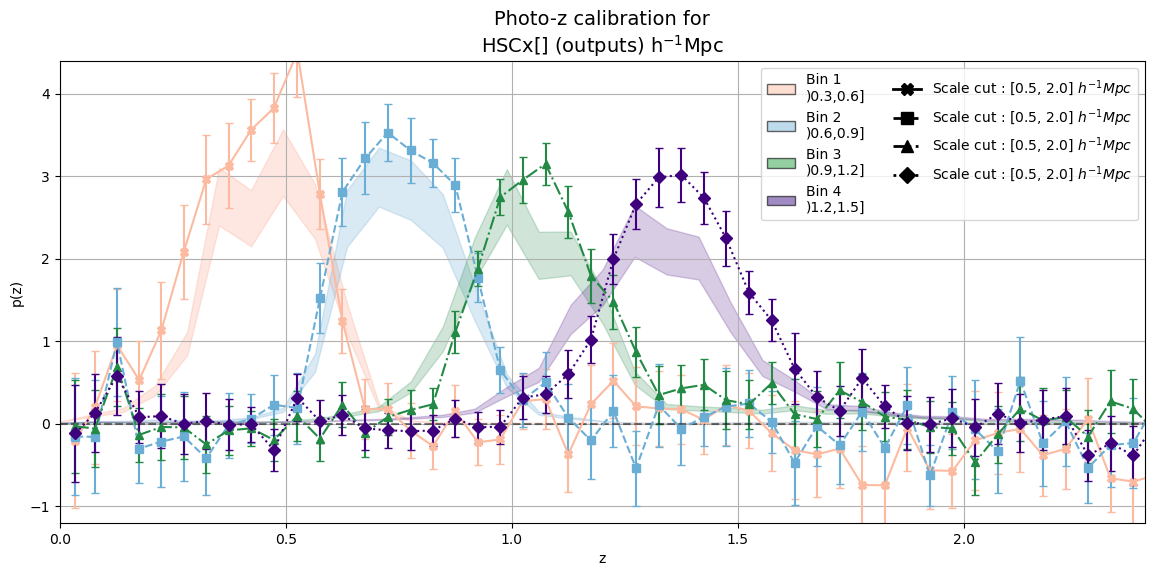

In [61]:
importlib.reload(inference)
importlib.reload(ct)
ncurves = 0
tracer_trad = {
    'BGS_ANY' : 'BGS',
    'LRG' : 'LRG',
    'ELGnotqso' : 'ELG',
    'QSO' : 'QSO',
}

bins_hsc = np.arange(0.3, 1.8, 0.3)

colormaps = [plt.get_cmap(c) for c in ['Reds', 'Blues', 'Greens', 'Purples']]
markers = ['X', 's', '^', 'D']
linestyles = ['-', '--', '-.', ':']
tomo_bin_dnnz = np.loadtxt('hsc_pz/data/tomographic_binning_dnnz.dat')

fig, ax = plt.subplots(figsize=(14, 6))

scale_cut = [0.5, 2]  # scale cuts for the analysis

tomo_interest = [1,2,3,4]  # tomographic bins of interest
title = 'Photo-z calibration for\nHSCx['
zbins = inference._get_fine_redshift_bins(fr=cf.CorrFileReader(path_dictionary["DESI_NGC"]))
redshifts = np.load('zeff/desi_z_clustering_catalogs.npy')
zeff = np.array(
    [np.mean(redshifts[(zbins[i] < redshifts) & (redshifts <= zbins[i+1])]) for i in range(len(zbins)-1)]
)
print(f'zeff = {zeff}')

nz = []
nz_err = []
for tomo in tomo_interest:
    tomo_nz, tomo_nz_err = inference.full_npz_tomo(
        do_bias_correction=False,
        path_dictionary=path_dictionary,
        scale_cuts=scale_cut,
        tracer="Merged",
        tomo_bin=tomo,
        rebin=1,
        )
    nonnanz = ~np.isnan(tomo_nz)
    tomo_nz = tomo_nz[nonnanz]
    tomo_nz_err = tomo_nz_err[nonnanz]
    zval = zeff[nonnanz]
    nz_int = simpson(tomo_nz, x=zval)
    nz.append(tomo_nz/nz_int)
    nz_err.append(tomo_nz_err/nz_int)
    tomo_index = tomo-1 if len(tomo_interest) > 1 else 0
    ax.errorbar(
        x=zval, 
        y=nz[tomo_index],
        yerr=nz_err[tomo_index],#/normalization, 
        capsize=3,
        marker=markers[tomo_index], 
        linestyle=linestyles[tomo_index],
        markersize=6,   
        alpha=1,
        color=colormaps[tomo_index]((tomo)/4),
        )
    
mids = tomo_bin_dnnz[:, 0]

dnnz_list = []
mu_list = []
cov_list = []

ids_to_skip = []

for dnnz_idx in range(0, 4):
    ncurves += 1

    dnnz, mu, cov = comb.hsc_dnnz_error(tomo_bin_dnnz[:, dnnz_idx+1], mids)
    dnnz_list.append(np.percentile(dnnz, 50, axis=0))
    mu_list.append(mu)
    cov_list.append(cov)

    ax.fill_between(
        mids, 
        np.percentile(dnnz, 16, axis=0), 
        np.percentile(dnnz, 84, axis=0), 
        color=colormaps[dnnz_idx]((dnnz_idx+2)/5), 
        alpha=0.2
        )
        
title+=f'] ({ROOT.name}) ' +r'$\rm{h}^{-1}\rm{Mpc}$'
ax.set_xlabel('z')
ax.set_ylabel('p(z)')

legend_elements = []

for bin_id in tomo_interest:
    patch = Patch(
        facecolor=colormaps[bin_id-1](bin_id/len(bins_hsc)),
        alpha=0.6,
        edgecolor='black',
        label=f'Bin {bin_id}\n){bins_hsc[bin_id-1]:.1f},{bins_hsc[bin_id]:.1f}]',
    )
    legend_elements.append(patch)

for i, (marker, linestyle, tracer) in enumerate(zip(markers, linestyles, tracers)):
    element = Line2D(
        [0], 
        [0], 
        color='black', 
        marker=marker, 
        linestyle=linestyle, 
        markersize=8, 
        label=f'Scale cut : [{scale_cut[0]:.1f}, {scale_cut[1]:.1f}] ' + r'$h^{-1}Mpc$', 
        linewidth=2
    )
    legend_elements.append(element)

ax.legend(
    handles=legend_elements, 
    loc='upper right', 
    ncol=2, 
    fontsize=10,
)

for i in range(len(nz)):
    print(f'Tomo {i+1} :')
    assert len(nz[i]) == len(zval), f'Length mismatch for tomo {i+1}'
    print(f'{simpson(np.multiply(mids, dnnz_list[i]), x=mids)}')
    print(f'{simpson(np.multiply(nz[i], zval), x=zval)}\n')

ax.axhline(0, color='black', linestyle='--', alpha=0.5)
ax.grid()
ax.set_title(title, fontsize=14)
ax.set_xlim(0, 2.4)
ax.set_ylim(-1.2, 4.4)

## Gaussian Process Models

In [49]:
stem = 'v15_dr1'
outdir = ROOT / f'merged_{stem}'
path_dictionary = {
    'HSC' : ROOT / 'v11_correction' / f'autos_HSC', # with no wpp correction, is unused
    'DESI_NGC' : ROOT / stem / f'autos_NGC',
    'DESI_SGC' : ROOT / stem / f'autos_SGC',
    'DESIxHSC' : ROOT / stem / f'cross',
    'MergedxMerged' : outdir,
    'MergedxHSC' : outdir,
}

In [38]:
inference.merge_estimators(
    path_dictionary=path_dictionary, 
    outdir=outdir, 
    tomo_interest=[1, 2, 3, 4],
    verbose=True,
)

Processing redshift bin 0 (Completion : 1.79%)
Processing redshift bin 5 (Completion : 10.71%)
Processing redshift bin 10 (Completion : 19.64%)
Processing redshift bin 15 (Completion : 28.57%)
Processing redshift bin 20 (Completion : 37.50%)
Processing redshift bin 25 (Completion : 46.43%)
Processing redshift bin 30 (Completion : 55.36%)
Processing redshift bin 35 (Completion : 64.29%)
Processing redshift bin 40 (Completion : 73.21%)
Processing redshift bin 45 (Completion : 82.14%)
Processing redshift bin 50 (Completion : 91.07%)
Processing redshift bin 55 (Completion : 100.00%)
Saved cross-correlation estimator to /global/cfs/projectdirs/desi/users/jchdj/desi-y3-hsc/src/statistics/outputs/merged_v14/MergedxHSC/MergedxHSC_b1x1_b2x1.npy
Saved cross-correlation estimator to /global/cfs/projectdirs/desi/users/jchdj/desi-y3-hsc/src/statistics/outputs/merged_v14/MergedxHSC/MergedxHSC_b1x1_b2x2.npy
Saved cross-correlation estimator to /global/cfs/projectdirs/desi/users/jchdj/desi-y3-hsc/src/

Using merged method for tracer Merged and tomo bin 1.
GP kernel: 0.944**2 * Matern(length_scale=0.1, nu=1.5)
Using merged method for tracer Merged and tomo bin 2.
GP kernel: 0.972**2 * Matern(length_scale=0.1, nu=1.5)
Using merged method for tracer Merged and tomo bin 3.
GP kernel: 0.645**2 * Matern(length_scale=0.1, nu=1.5)
Using merged method for tracer Merged and tomo bin 4.
GP kernel: 0.656**2 * Matern(length_scale=0.1, nu=1.5)


(-1.0, 4.5)

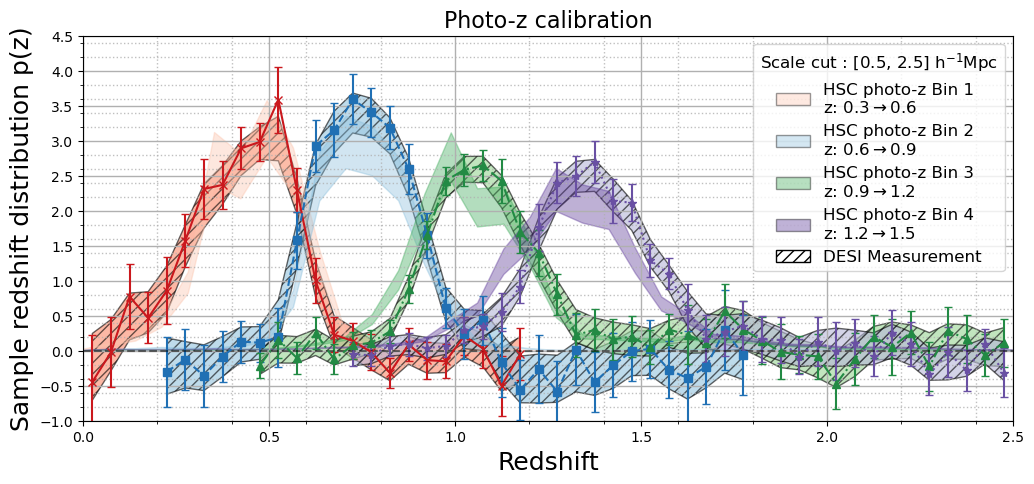

In [ ]:
importlib.reload(inference)
importlib.reload(comb)
importlib.reload(sgp)
ncurves = 0
tracer_trad = {
    'BGS_ANY' : 'BGS',
    'LRG' : 'LRG',
    'ELG_LOPnotqso' : 'ELG',
    'QSO' : 'QSO',
}

bins_hsc = np.arange(0.3, 1.8, 0.3)

colormaps = [plt.get_cmap(c) for c in ['Reds', 'Blues', 'Greens', 'Purples']]
markers = ['x', 's', '^', '*']
linestyles = ['-', '--', '-.', ':']
tomo_bin_dnnz = np.loadtxt('hsc_pz/data/tomographic_binning_dnnz.dat')

fig, ax = plt.subplots(figsize=(12, 5))

scale_cut = [.5, 2.5]

tomo_interest = [1,2,3,4]  # tomographic bins of interest
title = 'Photo-z calibration'
zbins = inference._get_fine_redshift_bins(fr=cf.CorrFileReader(path_dictionary["DESI_NGC"]))
redshifts = np.load('zeff/desi_z_clustering_catalogs.npy')
zeff = np.array(
    [np.mean(redshifts[(zbins[i] < redshifts) & (redshifts <= zbins[i+1])]) for i in range(len(zbins)-1)]
)
zeff = (zbins[1:] + zbins[:-1]) / 2  # use the midpoints of the bins as effective redshifts

nz = []
nz_err = []
for tomo_index, tomo in enumerate(tomo_interest):
    tomo_nz, tomo_nz_err = inference.full_npz_tomo(
        path_dictionary=path_dictionary,
        scale_cuts=scale_cut,
        do_bias_correction=False,
        tracer="Merged",
        tomo_bin=tomo,
        rebin=1,
        )
    if tomo == 1:
        zmask = (zeff >=0) & (zeff <= 1.2)
    if tomo > 1:
        zmask = (zeff >=0.2)
        if tomo == 2:
            zmask &= (zeff <= 1.8)
        if tomo == 3:
            zmask = (zeff >=0.45) & (zeff <= 2.5)
        if tomo == 4:
            zmask = (zeff >=0.7) & (zeff <= 2.5)


    nonnanz = ~np.isnan(tomo_nz)
    mask_tomo = nonnanz & zmask
    tomo_nz = tomo_nz[mask_tomo]
    tomo_nz_err = tomo_nz_err[mask_tomo]
    zval = zeff[mask_tomo]
    nz_int = simpson(tomo_nz, x=zval)
    nz.append(tomo_nz/nz_int)
    nz_err.append(tomo_nz_err/nz_int)

    dz = np.diff(zval)[0]
    y_mean, y_std = sgp.gpfit(zval, (tomo_nz/nz_int, tomo_nz_err/nz_int))

    ax.fill_between(
        zval,
        y_mean - y_std,
        y_mean + y_std,
        alpha=0.6,
        color=colormaps[tomo-1](0.4),
        edgecolor='black',
        label=f'GP',
        hatch='///'
    )

    ax.errorbar(
        x=zval, 
        y=nz[tomo-1 if len(tomo_interest) > 1 else tomo_index],
        yerr=nz_err[tomo-1 if len(tomo_interest) > 1 else tomo_index],#/normalization, 
        capsize=3,
        marker=markers[tomo-1], 
        linestyle=linestyles[tomo-1],
        markersize=6,   
        alpha=1,
        color=colormaps[tomo-1](3/4),
        )
        
    #title+= f'x{tracer_trad[tracers[tomo-1]]}'

mids = tomo_bin_dnnz[:, 0]
mask_mids = mids < 2.725

dnnz_list = []
mu_list = []
cov_list = []

ids_to_skip = []

for dnnz_idx in range(1, 5):
    if dnnz_idx not in tomo_interest:
        continue
    ncurves += 1
    
    dnnz, mu, cov = comb.hsc_dnnz_error(tomo_bin_dnnz[:, dnnz_idx], mids)
    dnnz_list.append(np.percentile(dnnz, 50, axis=0))
    mu_list.append(mu)
    cov_list.append(cov)

    if len(tomo_interest) == 1:
        col = 'gray'
    else:
        col = colormaps[dnnz_idx-1]((dnnz_idx+0.1)/len(bins_hsc))

    ax.fill_between(
        mids, 
        np.percentile(dnnz, 16, axis=0), 
        np.percentile(dnnz, 84, axis=0), 
        color=col, 
        alpha=0.4
        )
        
#title+=f'] ' +r'$\rm{h}^{-1}\rm{Mpc}$'
ax.set_xlabel('Redshift', fontsize=18)
ax.set_ylabel('Sample redshift distribution p(z)', fontsize=18)

legend_elements = []

for bin_id in tomo_interest:
    if len(tomo_interest) == 1:
        col = 'gray'
    else:
        col = colormaps[bin_id-1](bin_id/len(bins_hsc))
    patch = Patch(
        facecolor=col,
        alpha=0.4,
        edgecolor='black',
        label=f'HSC photo-z Bin {bin_id}\n'
        #+ r'$\mathcal{L}_{\mathrm{\tt{DNNz}}}$' 
        + f'z: {bins_hsc[bin_id-1]:.1f}' +r'$\rightarrow$' + f'{bins_hsc[bin_id]:.1f}',
    )
    legend_elements.append(patch)
legend_elements.append(Patch(
        facecolor='white',
        edgecolor='black',
        label='DESI Measurement',
        hatch='///',
    ))

for i, (marker, linestyle, tracer) in enumerate(zip(markers, linestyles, tracers)):
    if i+1 not in tomo_interest:
        continue
    element = Line2D(
        [0], 
        [0], 
        color='black', 
        marker=marker, 
        linestyle=linestyle, 
        markersize=8, 
        label=f'Scale cut : [{scale_cut[0]:.1f}, {scale_cut[1]:.1f}] ' + r'h$^{-1}$Mpc', 
        linewidth=2
    )
    #legend_elements.append(element)

ax.legend(
    handles=legend_elements, 
    loc='upper right', 
    ncol=1 if len(tomo_interest) == 1 else 1, 
    fontsize=12 if len(tomo_interest) == 1 else 12,
    title=f'Scale cut : [{scale_cut[0]:.1f}, {scale_cut[1]:.1f}] ' + r'h$^{-1}$Mpc',
    title_fontsize=14 if len(tomo_interest) == 1 else 12,
)

#for i in range(len(nz)):
#    print(f'Tomo {i+1} :')
#    assert len(nz[i]) == len(zval), f'Length mismatch for tomo {i+1}'
#    print(f'{simpson(np.multiply(mids, dnnz_list[i]), x=mids)}')
#    print(f'{simpson(np.multiply(nz[i], zval), x=zval)}\n')

ax.axhline(0, color='black', linestyle='--', alpha=0.5)

# X-axis: major ticks every 0.5, minor every 0.2
ax.xaxis.set_major_locator(MultipleLocator(0.5))
ax.xaxis.set_minor_locator(MultipleLocator(0.2))

# Y-axis: major ticks every 0.5, minor every 0.2
ax.yaxis.set_major_locator(MultipleLocator(0.5))
ax.yaxis.set_minor_locator(MultipleLocator(0.2))

# Grid styling
ax.grid(which='major', linestyle='-', linewidth=1)
ax.grid(which='minor', linestyle=':', linewidth=1, alpha=0.8)

ax.set_title(title, fontsize=16)
ax.set_xlim(0., 2.5)
ax.set_ylim(-1, 4.5)

Tracer BGS_ANY
[0.025 0.075 0.125 0.175 0.225 0.275 0.325 0.375 0.425 0.475]
Computing n(z) for tracer BGS_ANY and tomo bin 1
Using standard method for tracer BGS_ANY and tomo bin 1.
Computing n(z) for tracer BGS_ANY and tomo bin 2
Using standard method for tracer BGS_ANY and tomo bin 2.
Computing n(z) for tracer BGS_ANY and tomo bin 3
Using standard method for tracer BGS_ANY and tomo bin 3.
Computing n(z) for tracer BGS_ANY and tomo bin 4
Using standard method for tracer BGS_ANY and tomo bin 4.
Tracer LRG
[0.425 0.475 0.525 0.575 0.625 0.675 0.725 0.775 0.825 0.875 0.925 0.975
 1.025 1.075]
Computing n(z) for tracer LRG and tomo bin 1
Using standard method for tracer LRG and tomo bin 1.
Computing n(z) for tracer LRG and tomo bin 2
Using standard method for tracer LRG and tomo bin 2.
Computing n(z) for tracer LRG and tomo bin 3
Using standard method for tracer LRG and tomo bin 3.
Computing n(z) for tracer LRG and tomo bin 4
Using standard method for tracer LRG and tomo bin 4.
Tracer EL

(-1.2, 3.8)

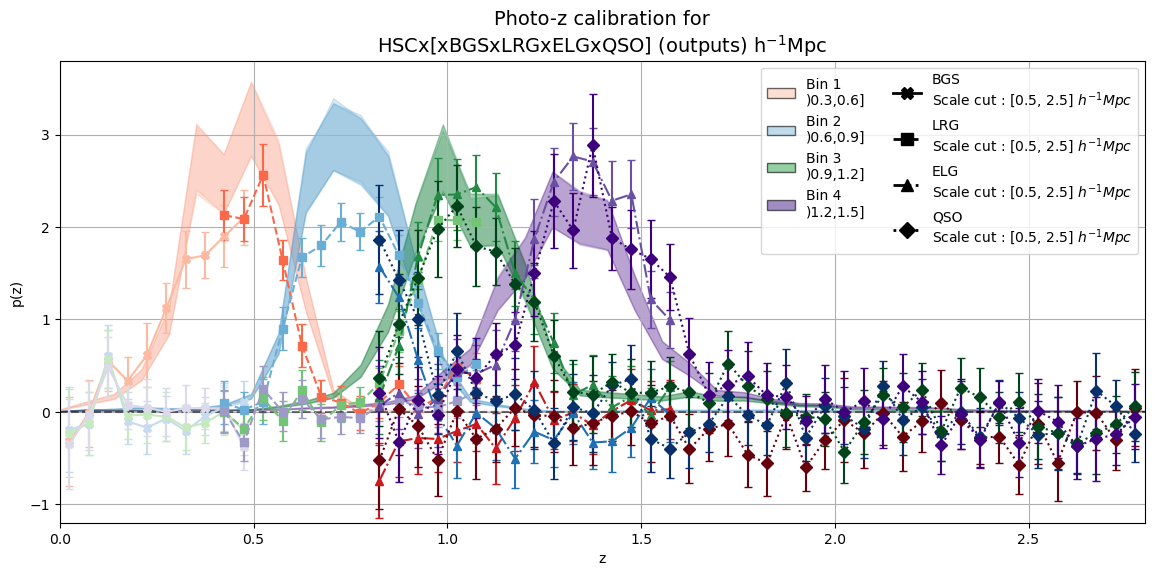

In [50]:
importlib.reload(inference)
ncurves = 0
tracers = ['BGS_ANY', 'LRG', 'ELG_LOPnotqso', 'QSO'] #'LRG', 'ELGnotqso', 'QSO'] #'LRG', 'ELGnotqso', 'QSO']#'ELGnotqso', 'QSO']
tracer_trad = {
    'BGS_ANY' : 'BGS',
    'LRG' : 'LRG',
    'ELG_LOPnotqso' : 'ELG',
    'QSO' : 'QSO',
}

# tomographic binning...
bins_hsc = np.arange(0.3, 1.8, 0.3)

colormaps = [plt.get_cmap(c) for c in ['Reds', 'Blues', 'Greens', 'Purples']]
markers = ['X', 's', '^', 'D']
linestyles = ['-', '--', '-.', ':']

tomo_bin_dnnz = np.loadtxt('hsc_pz/data/tomographic_binning_dnnz.dat')

fig, ax = plt.subplots(figsize=(14, 6))

# only looking at tomo 3
tomo_interest = [1,2,3,4]

scale_cuts = [[.5, 2.5]] # in Mpc/h #[[0.2, 2.5], [0.2, 2.5], [0.2, 5], [0.5, 5]]
if scale_cuts is not None and len(scale_cuts) == 1:
    scale_cuts = [scale_cuts[0] for _ in range(len(tracers))]

title = 'Photo-z calibration for\nHSCx['
for n in range(len(tracers)):
    t = tracers[n]
    print(f"Tracer {t}")
    bins_tracer = cf.CorrFileReader(
        path_dictionary['DESI_NGC'],
        ).get_bins(t)
    zval = bins_tracer[:-1] + np.diff(bins_tracer) / 2
    print(zval)
    range_tracer = [bins_tracer[0], bins_tracer[-1]]
    mask = (tomo_bin_dnnz[:, 0] >= min(bins_tracer)) & (tomo_bin_dnnz[:, 0] <= max(bins_tracer))
    mids = tomo_bin_dnnz[:, 0]
    mask_mids = tomo_bin_dnnz[mask, 0]

    dnnz_list = []
    mu_list = []
    cov_list = []

    ids_to_skip = []
    nz = []
    nz_err = []

    for tomo in tomo_interest:
        print(f"Computing n(z) for tracer {t} and tomo bin {tomo}")
        tomo_nz, tomo_nz_err = inference.full_npz_tomo(
                path_dictionary=path_dictionary,
                scale_cuts=scale_cuts[n],
                tracer=t,
                tomo_bin=tomo,
                do_bias_correction=False,
                rebin=1,
                )
        nz.append(tomo_nz)
        nz_err.append(tomo_nz_err)
        
    area_ratio = []

    for outlier_idx in range(len(tomo_interest)):
        if max(range_tracer[0], bins_hsc[outlier_idx]) > min(range_tracer[1], bins_hsc[outlier_idx+1]):
            ids_to_skip.append(outlier_idx)

    for dnnz_idx in range(0, 4):
        ncurves += 1

        dnnz, mu, cov = comb.hsc_dnnz_error(tomo_bin_dnnz[:, dnnz_idx+1], mids)
        area_ratio.append(simpson(np.percentile(dnnz, 50, axis=0)[mask], x=mask_mids))

        if dnnz_idx in ids_to_skip:
            continue
        ax.fill_between(
            mids, 
            np.percentile(dnnz, 16, axis=0), 
            np.percentile(dnnz, 84, axis=0), 
            color=colormaps[dnnz_idx]((dnnz_idx+2)/5), 
            alpha=0.2
            )
        
    for x, j in enumerate(tomo_interest):
        if j in ids_to_skip and t=='QSO':
            continue
        mask = ~np.isnan(nz[x])
        #normalization = simpson(nz[x][mask], x=zval[mask])/area_ratio[x]
        #if normalization > 0:
        ax.errorbar(
            x=zval[mask], 
            y=nz[x][mask],#/normalization,
            yerr=nz_err[x][mask],#/normalization, 
            capsize=3,
            marker=markers[n], 
            linestyle=linestyles[n],
            markersize=6,   
            alpha=1,
            color=colormaps[j-1]((n+1)/4),
            )
        
    title+= f'x{tracer_trad[tracers[n]]}'

#ax.plot(
#    np.linspace(0, 7, 100),
#    normalized_pdf_tail, 
#    color='black', 
#    linestyle='--', 
#    label='Best sum PDF tail',
#    alpha=1,
#    linewidth=2,
#)

title+=f'] ({ROOT.name}) ' +r'$\rm{h}^{-1}\rm{Mpc}$'
ax.set_xlabel('z')
ax.set_ylabel('p(z)')

legend_elements = []

for bin_id in tomo_interest:
    patch = Patch(
        facecolor=colormaps[bin_id-1]((bin_id)/len(bins_hsc)),
        alpha=0.6,
        edgecolor='black',
        label=f'Bin {bin_id}\n){bins_hsc[bin_id-1]:.1f},{bins_hsc[bin_id]:.1f}]',
    )
    legend_elements.append(patch)

for i, (marker, linestyle, tracer) in enumerate(zip(markers, linestyles, tracers)):
    element = Line2D(
        [0], 
        [0], 
        color='black', 
        marker=marker, 
        linestyle=linestyle, 
        markersize=8, 
        label=tracer_trad[tracer] + f'\nScale cut : [{scale_cuts[i][0]:.1f}, {scale_cuts[i][1]:.1f}] ' + r'$h^{-1}Mpc$', 
        linewidth=2
    )
    legend_elements.append(element)

ax.legend(
    handles=legend_elements, 
    loc='upper right', 
    ncol=2, 
    fontsize=10,
)

ax.axhline(0, color='black', linestyle='--', alpha=0.5)
ax.grid()
ax.set_title(title, fontsize=14)
ax.set_xlim(0, 2.8)
ax.set_ylim(-1.2, 3.8)

Magnification bias corrections :

$ w_{sp}(z_i) = n_p(z_i) b_p(z_i) b_s(z_i) w_{\mathrm{DM}}(z_i) + 
b_s(z_i) \alpha_p(z_i) \sum_{j>i} \left[ D_{ij} n_p(z_j) \right] + 
b_p(z_i) \alpha_s(z_i) \sum_{j>i} \left[ D_{ij} n_p(z_i) \right] $  

$ \frac{w_{sp}(z_i)}{\Delta z\sqrt{w_{pp}(z_i)w_{ss}(z_i)}} = n_p(z_i) + 
\frac{\alpha_p(z_i)}{b_p(z_i)} \sum_{j>i} \left[ D_{ij}^n n_p(z_j) \right] + 
\frac{\alpha_s(z_i)}{b_s(z_i)} \sum_{j>i} \left[ D_{ij}^n n_p(z_i) \right] $  

$ D_{ij}^n = \frac{D_{ij}}{w_{\mathrm{DM}}(z_i)} $  

$ D_{ij} = \frac{3 H_0^2 \Omega_m}{c^2} w_{\mathrm{DM}}(z_i)
\frac{\chi(z_j)\left[ \chi(z_j) - \chi(z_i) \right]}{a(z_i) \chi(z_j)} \Delta \chi_j $  

### Gaussian Mixture